# Run Appendix and Robustness Analysis

This notebook is the appendix replication entry point. It runs the appendix workflow from `analysis/src/workflows.py`, regenerates the appendix-facing exports, and displays the core robustness tables and figures inline from `analysis/output/`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "analysis" / "src").exists()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Could not locate project root containing analysis/src.")

project_root = project_root.resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)


In [2]:
from analysis.src.config import (
    ROBUSTNESS_SUMMARY_TABLE_PATH,
    WITHIN_GENRE_ROBUSTNESS_TABLE_PATH,
    WITHIN_GENRE_SELECTION_ROBUSTNESS_TABLE_PATH,
    WITHIN_GENRE_REPEATED_HOLDOUT_SUMMARY_TABLE_PATH,
    WITHIN_GENRE_REPEATED_HOLDOUT_RAW_TABLE_PATH,
    WITHIN_GENRE_ALL_ELIGIBLE_COMPARISON_TABLE_PATH,
    WITHIN_GENRE_SELECTION_ROBUSTNESS_FIGURE_PATH,
    GENRE_PROFILE_SUMMARY_TABLE_PATH,
    GENRE_DEVIATION_ROBUSTNESS_TABLE_PATH,
)
from analysis.src.workflows import run_appendix_robustness_workflow


## Run Workflow

Run the appendix workflow first. The tables and figures below are read back from the exported output files.

In [3]:
appendix_results = run_appendix_robustness_workflow(project_root)
appendix_results["sample_overview"]


{'robustness_shape': (89741, 19),
 'robustness_audit': {'row_count': 89741,
  'unique_track_id_count': 89741,
  'duplicate_track_id_count': 0,
  'multi_genre_track_id_count': 0,
  'missingness_by_column': {'track_id': 0,
   'popularity': 0,
   'duration_ms': 0,
   'explicit': 0,
   'danceability': 0,
   'energy': 0,
   'key': 0,
   'loudness': 0,
   'mode': 0,
   'speechiness': 0,
   'acousticness': 0,
   'instrumentalness': 0,
   'liveness': 0,
   'valence': 0,
   'tempo': 0,
   'time_signature': 0,
   'track_genre': 0,
   'genre_count': 0,
   'had_multiple_genres': 0},
  'dtypes': {'track_id': 'object',
   'popularity': 'int64',
   'duration_ms': 'int64',
   'explicit': 'bool',
   'danceability': 'float64',
   'energy': 'float64',
   'key': 'int64',
   'loudness': 'float64',
   'mode': 'int64',
   'speechiness': 'float64',
   'acousticness': 'float64',
   'instrumentalness': 'float64',
   'liveness': 'float64',
   'valence': 'float64',
   'tempo': 'float64',
   'time_signature': 'int

## Generated Outputs

These are the appendix outputs that the notebook previews inline.

In [4]:
def to_abs_path(relative_path):
    return (project_root / relative_path).resolve()


def show_table(relative_path, title, round_digits=3):
    path = to_abs_path(relative_path)
    frame = pd.read_csv(path)
    numeric_columns = frame.select_dtypes(include="number").columns
    display(Markdown(f"### {title}\n`{relative_path.as_posix()}`"))
    display(frame.round({column: round_digits for column in numeric_columns}))
    return frame


def show_figure(relative_path, title, width=900):
    path = to_abs_path(relative_path)
    display(Markdown(f"### {title}\n`{relative_path.as_posix()}`"))
    display(Image(filename=str(path), width=width))
    return path

output_manifest = pd.DataFrame(
    [
        {"section": "appendix", "kind": "table", "label": "Robustness summary table", "path": ROBUSTNESS_SUMMARY_TABLE_PATH.as_posix()},
        {"section": "appendix", "kind": "table", "label": "Within-genre robustness table", "path": WITHIN_GENRE_ROBUSTNESS_TABLE_PATH.as_posix()},
        {"section": "appendix", "kind": "table", "label": "Selection-rule robustness", "path": WITHIN_GENRE_SELECTION_ROBUSTNESS_TABLE_PATH.as_posix()},
        {"section": "appendix", "kind": "table", "label": "Repeated holdout summary", "path": WITHIN_GENRE_REPEATED_HOLDOUT_SUMMARY_TABLE_PATH.as_posix()},
        {"section": "appendix", "kind": "table", "label": "Repeated holdout raw results", "path": WITHIN_GENRE_REPEATED_HOLDOUT_RAW_TABLE_PATH.as_posix()},
        {"section": "appendix", "kind": "table", "label": "All-eligible comparison", "path": WITHIN_GENRE_ALL_ELIGIBLE_COMPARISON_TABLE_PATH.as_posix()},
        {"section": "appendix", "kind": "table", "label": "Genre profile summary", "path": GENRE_PROFILE_SUMMARY_TABLE_PATH.as_posix()},
        {"section": "appendix", "kind": "table", "label": "Genre-deviation robustness", "path": GENRE_DEVIATION_ROBUSTNESS_TABLE_PATH.as_posix()},
        {"section": "appendix", "kind": "figure", "label": "Selection-rule robustness figure", "path": WITHIN_GENRE_SELECTION_ROBUSTNESS_FIGURE_PATH.as_posix()},
    ]
)
output_manifest


,section,kind,label,path
0,appendix,table,Robustness summary table,analysis/output/tables/robustness_summary_tabl...
1,appendix,table,Within-genre robustness table,analysis/output/tables/within_genre_robustness...
2,appendix,table,Selection-rule robustness,analysis/output/tables/within_genre_selection_...
3,appendix,table,Repeated holdout summary,analysis/output/tables/within_genre_repeated_h...
4,appendix,table,Repeated holdout raw results,analysis/output/tables/within_genre_repeated_h...
5,appendix,table,All-eligible comparison,analysis/output/tables/within_genre_all_eligib...
6,appendix,table,Genre profile summary,analysis/output/tables/genre_profile_summary_t...
7,appendix,table,Genre-deviation robustness,analysis/output/tables/genre_deviation_robustn...
8,appendix,figure,Selection-rule robustness figure,analysis/output/figures/within_genre_selection...


## Robustness Tables

In [5]:
_ = show_table(ROBUSTNESS_SUMMARY_TABLE_PATH, "Robustness summary table")
_ = show_table(WITHIN_GENRE_ROBUSTNESS_TABLE_PATH, "Within-genre robustness table")
_ = show_table(WITHIN_GENRE_SELECTION_ROBUSTNESS_TABLE_PATH, "Selection-rule robustness")
_ = show_table(WITHIN_GENRE_REPEATED_HOLDOUT_SUMMARY_TABLE_PATH, "Repeated holdout summary")
_ = show_table(WITHIN_GENRE_ALL_ELIGIBLE_COMPARISON_TABLE_PATH, "All-eligible comparison")


### Robustness summary table
`analysis/output/tables/robustness_summary_table.csv`

,model_name,model_type,term,coefficient,std_error,p_value,fit_metric_name,fit_metric_value,n_obs
0,binary_top_quartile,Logit,Key = 1,0.115,0.035,0.001,mcfadden_pseudo_r2,0.038,89741
1,binary_top_quartile,Logit,Key = 2,0.017,0.034,0.624,mcfadden_pseudo_r2,0.038,89741
2,binary_top_quartile,Logit,Key = 3,0.202,0.050,0.000,mcfadden_pseudo_r2,0.038,89741
3,binary_top_quartile,Logit,Key = 4,0.032,0.037,0.385,mcfadden_pseudo_r2,0.038,89741
4,binary_top_quartile,Logit,Key = 5,0.103,0.036,0.004,mcfadden_pseudo_r2,0.038,89741
5,binary_top_quartile,Logit,Key = 6,0.150,0.038,0.000,mcfadden_pseudo_r2,0.038,89741
6,binary_top_quartile,Logit,Key = 7,-0.085,0.033,0.012,mcfadden_pseudo_r2,0.038,89741
7,binary_top_quartile,Logit,Key = 8,0.224,0.039,0.000,mcfadden_pseudo_r2,0.038,89741
8,binary_top_quartile,Logit,Key = 9,-0.056,0.035,0.107,mcfadden_pseudo_r2,0.038,89741
9,binary_top_quartile,Logit,Key = 10,0.084,0.039,0.030,mcfadden_pseudo_r2,0.038,89741


### Within-genre robustness table
`analysis/output/tables/within_genre_robustness_table.csv`

,model_type,term_group,term,coefficient,std_error,p_value,fit_metric_name,fit_metric_value,n_obs
0,Logit,control,Key = 1,0.088,0.254,0.730,mcfadden_pseudo_r2,0.366,2760.0
1,Logit,control,Key = 2,-0.015,0.280,0.957,mcfadden_pseudo_r2,0.366,2760.0
2,Logit,control,Key = 3,0.609,0.378,0.107,mcfadden_pseudo_r2,0.366,2760.0
3,Logit,control,Key = 4,0.124,0.286,0.665,mcfadden_pseudo_r2,0.366,2760.0
4,Logit,control,Key = 5,0.321,0.279,0.250,mcfadden_pseudo_r2,0.366,2760.0
5,Logit,control,Key = 6,-0.696,0.269,0.010,mcfadden_pseudo_r2,0.366,2760.0
6,Logit,control,Key = 7,0.092,0.265,0.728,mcfadden_pseudo_r2,0.366,2760.0
7,Logit,control,Key = 8,0.177,0.303,0.559,mcfadden_pseudo_r2,0.366,2760.0
8,Logit,control,Key = 9,-0.049,0.279,0.861,mcfadden_pseudo_r2,0.366,2760.0
9,Logit,control,Key = 10,-0.023,0.280,0.934,mcfadden_pseudo_r2,0.366,2760.0


### Selection-rule robustness
`analysis/output/tables/within_genre_selection_rule_robustness.csv`

,min_count,selected_genres,n_genres,sample_size,no_interaction_adj_r2,interaction_adj_r2,adj_r2_gain,wald_test_type,wald_statistic,wald_df,wald_p_value
0,250,pop | rock | hip-hop | jazz | electronic,5,2374,0.292,0.316,0.024,Wald chi-square,76.267,12,0.0
1,300,pop | rock-n-roll | hip-hop | jazz | electronic,5,2760,0.314,0.338,0.024,Wald chi-square,83.050,12,0.0
2,350,pop | rock-n-roll | hip-hop | jazz | electronic,5,2760,0.314,0.338,0.024,Wald chi-square,83.050,12,0.0
3,400,pop | rock-n-roll | hip-hop | jazz | electronic,5,2760,0.314,0.338,0.024,Wald chi-square,83.050,12,0.0


### Repeated holdout summary
`analysis/output/tables/within_genre_repeated_holdout_summary.csv`

,n_repetitions,mean_test_r2_gain,std_test_r2_gain,min_test_r2_gain,max_test_r2_gain,mean_rmse_reduction,std_rmse_reduction,min_rmse_reduction,max_rmse_reduction
0,10,0.017,0.013,-0.011,0.029,0.262,0.206,-0.171,0.461


### All-eligible comparison
`analysis/output/tables/within_genre_all_eligible_comparison.csv`

,analysis_scope,n_genres,sample_size,selected_genres,no_interaction_adj_r2,interaction_adj_r2,adj_r2_gain,wald_test_type,wald_statistic,wald_df,wald_p_value
0,market_facing_subset,5,2760,pop | rock-n-roll | hip-hop | jazz | electronic,0.314,0.338,0.024,Wald chi-square,83.050,12,0.0
1,all_eligible_genres,89,68069,tango | study | sleep | idm | comedy | iranian...,0.433,0.459,0.026,Wald chi-square,3166.023,264,0.0


## Supporting Appendix Tables

In [6]:
_ = show_table(WITHIN_GENRE_REPEATED_HOLDOUT_RAW_TABLE_PATH, "Repeated holdout raw results")
_ = show_table(GENRE_PROFILE_SUMMARY_TABLE_PATH, "Genre profile summary")
_ = show_table(GENRE_DEVIATION_ROBUSTNESS_TABLE_PATH, "Genre-deviation robustness")


### Repeated holdout raw results
`analysis/output/tables/within_genre_repeated_holdout_raw.csv`

,random_state,model_name,test_r2,test_rmse,n_train,n_test,group_overlap_count,r2_gain_vs_no_interaction,rmse_reduction_vs_no_interaction
0,42,no_interaction,0.304,20.677,2208,552,0,0.000,0.000
1,42,interaction_aware,0.333,20.236,2208,552,0,0.029,0.441
2,43,no_interaction,0.340,20.439,2208,552,0,0.000,0.000
3,43,interaction_aware,0.362,20.093,2208,552,0,0.022,0.346
4,44,no_interaction,0.352,20.790,2208,552,0,0.000,0.000
5,44,interaction_aware,0.380,20.329,2208,552,0,0.028,0.461
6,45,no_interaction,0.278,21.672,2208,552,0,0.000,0.000
7,45,interaction_aware,0.273,21.744,2208,552,0,-0.005,-0.072
8,46,no_interaction,0.313,21.667,2208,552,0,0.000,0.000
9,46,interaction_aware,0.302,21.837,2208,552,0,-0.011,-0.171


### Genre profile summary
`analysis/output/tables/genre_profile_summary_table.csv`

,genre,feature,genre_mean,genre_std,n_obs
0,pop,danceability,0.580,0.140,412
1,rock-n-roll,danceability,0.550,0.139,660
2,hip-hop,danceability,0.724,0.127,540
3,jazz,danceability,0.488,0.149,452
4,electronic,danceability,0.659,0.130,696
5,pop,energy,0.578,0.201,412
6,rock-n-roll,energy,0.507,0.170,660
7,hip-hop,energy,0.690,0.142,540
8,jazz,energy,0.306,0.166,452
9,electronic,energy,0.694,0.185,696


### Genre-deviation robustness
`analysis/output/tables/genre_deviation_robustness_table.csv`

,term_group,term,coefficient,std_error,p_value,n_obs,adj_r2
0,control,Key = 1,-0.909,1.684,0.590,2760.0,0.314
1,control,Key = 2,-0.743,1.684,0.659,2760.0,0.314
2,control,Key = 3,1.694,2.365,0.474,2760.0,0.314
3,control,Key = 4,1.127,1.776,0.526,2760.0,0.314
4,control,Key = 5,0.184,1.727,0.915,2760.0,0.314
5,control,Key = 6,-7.945,2.190,0.000,2760.0,0.314
6,control,Key = 7,1.255,1.634,0.442,2760.0,0.314
7,control,Key = 8,0.783,2.312,0.735,2760.0,0.314
8,control,Key = 9,-2.052,1.608,0.202,2760.0,0.314
9,control,Key = 10,0.231,2.167,0.915,2760.0,0.314


## Figure

### Selection-rule robustness figure
`analysis/output/figures/within_genre_selection_rule_robustness.png`

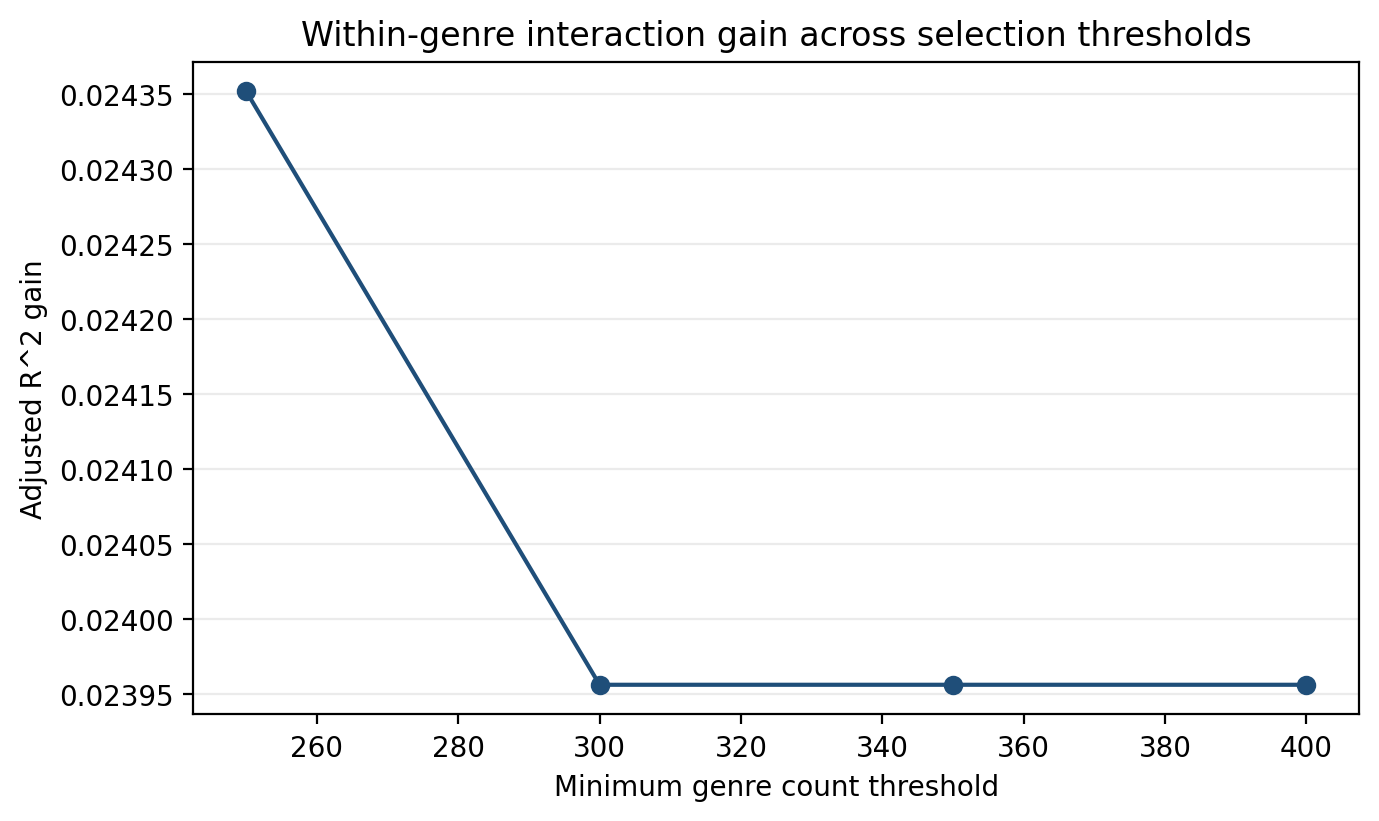

In [7]:
_ = show_figure(WITHIN_GENRE_SELECTION_ROBUSTNESS_FIGURE_PATH, "Selection-rule robustness figure")
